## Library 

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
from moviepy import VideoFileClip, concatenate_videoclips

## Folder Configuration

In [2]:
animation_dir = os.path.join('.', 'output', 'animation')

## RK4-CS Stability Region

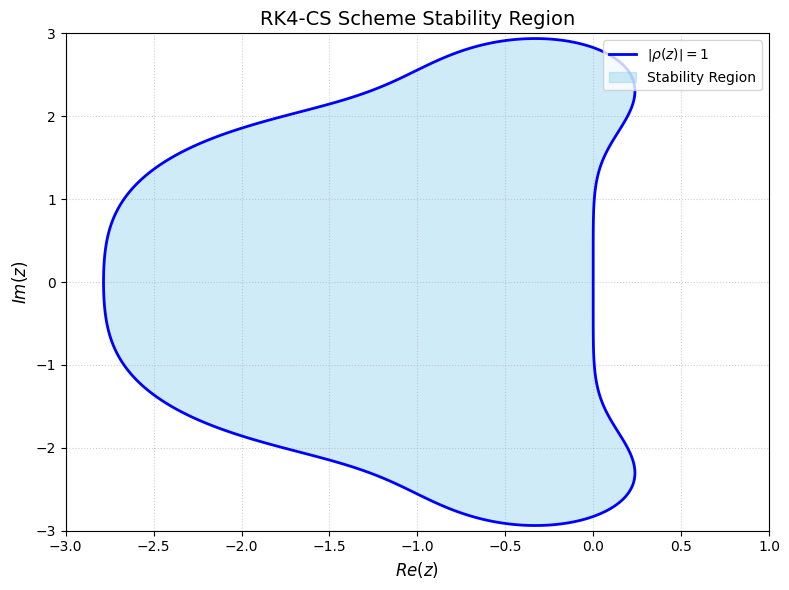

In [3]:
x = np.linspace(-3.0, 1.0, 500)
y = np.linspace(-3.0, 3.0, 500)
X, Y = np.meshgrid(x, y)
Z = X + 1j*Y

# Amplification factor
G = 1 + Z + Z**2/2 + Z**3/6 + Z**4/24
Magnitude = np.abs(G)

plt.figure(figsize=(8, 6))

plt.contourf(X, Y, Magnitude, levels=[0, 1], colors=['skyblue'], alpha=0.4)
plt.contour(X, Y, Magnitude, levels=[1], colors='blue', linewidths=2)

plt.title('RK4-CS Scheme Stability Region', fontsize=14)
plt.xlabel(r'$Re(z)$', fontsize=12)
plt.ylabel(r'$Im(z)$', fontsize=12)

plt.xlim(-3.0, 1.0)
plt.ylim(-3.0, 3.0)
plt.grid(True, linestyle=':', alpha=0.6)

plt.plot([], [], color='blue', linewidth=2, label=r'$\left|\rho(z)\right| = 1$')
plt.fill_between([], [], color='skyblue', alpha=0.4, label='Stability Region')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## FTCS Stability Region

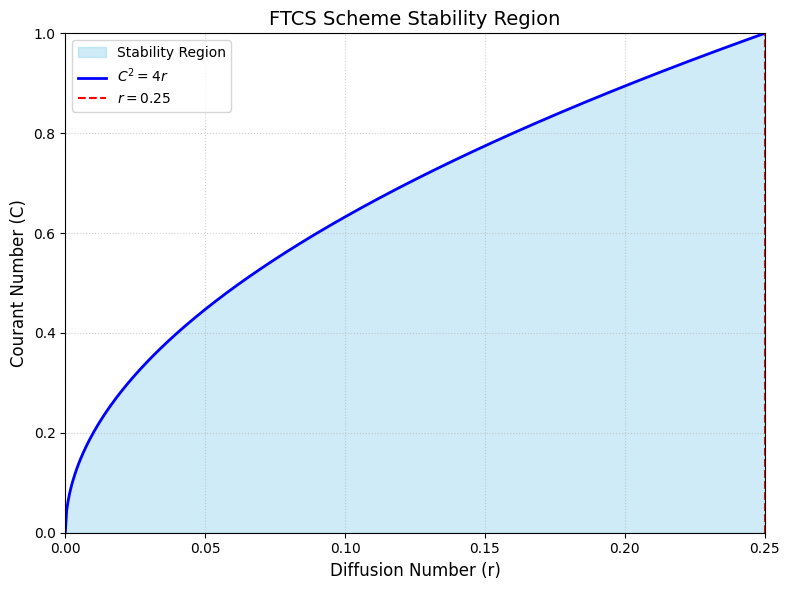

In [4]:
r = np.linspace(0, 0.25, 500)
C_limit = np.sqrt(4*r)

plt.figure(figsize=(8, 6))

plt.fill_between(r, 0, C_limit, color='skyblue', alpha=0.4, label='Stability Region')

plt.plot(r, C_limit, color='blue', linewidth=2, label=r'$C^{2} = 4r$')
plt.axvline(x=0.25, color='red', linestyle='--', label=r'$r = 0.25$')

plt.title('FTCS Scheme Stability Region', fontsize=14)
plt.xlabel('Diffusion Number (r)', fontsize=12)
plt.ylabel('Courant Number (C)', fontsize=12)

plt.xlim(0, 0.25)
plt.ylim(0, 1.0)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

## Video Combiner

In [7]:
def combine_video(video_list, output_name):
    clips = []
    try:
        for video in video_list:
            clip = VideoFileClip(video)
            clips.append(clip)

        video_final = concatenate_videoclips(clips, method="compose")
        video_final.write_videofile(output_name, codec="libx264")

    except Exception as e:
        print(f"Error: {e}")
        
    finally:
        for clip in clips:
            clip.close()

list_file = ["ftcsre5000part1.mp4", "ftcsre5000part2.mp4", "ftcsre5000part3.mp4", "ftcsre5000part4.mp4"]
list_file = [os.path.join(animation_dir, file) for file in list_file]
output_dir = os.path.join(animation_dir, 'ftcsre5000.mp4')

combine_video(list_file, output_dir)

MoviePy - Building video .\output\animation\ftcsre5000.mp4.
MoviePy - Writing video .\output\animation\ftcsre5000.mp4



MoviePy - Done !
MoviePy - video ready .\output\animation\ftcsre5000.mp4
